# IPL Team Performance Analysis  
## Case Study: Royal Challengers Bangalore (RCB)

## Objective

This project analyzes the performance of Royal Challengers Bangalore (RCB) in the IPL to identify key factors influencing match outcomes.

Key questions:
- Does winning the toss impact RCB’s performance?
- Does RCB perform better while chasing or batting first?
- Which teams does RCB struggle against?
- How dependent is RCB on Virat Kohli’s performance?

## Dataset

The dataset includes IPL match-level and ball-by-ball data from 2008–2022.

Files used:
- Matches dataset (team-level information)
- Ball-by-ball dataset (player-level performance)

## Data Preparation

- Filtered matches involving RCB
- Created a binary variable for match outcomes (win/loss)
- Standardized team and player data

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import os
print(os.listdir())

['IPL_Ball_by_Ball_2008_2022.csv', '.Rhistory', '.config', 'Music', 'Lab-1.docx', 'Python MDC_Group7.ipynb', 'ASYNCHRONOUS SEP 17.ipynb', '.condarc', 'assignment_results.csv', 'Using Panda.ipynb', 'Untitled1.ipynb', 'Patterns .ipynb', '.DS_Store', 'Basic Math .ipynb', '.CFUserTextEncoding', '.xonshrc', 'anaconda_projects', 'Lab8_2440813.docx', 'Untitled.ipynb', 'Sample questions.ipynb', '.zshrc', 'Lab5_2440813.docx', 'matches.csv', 'Mid Sem Exam_2440813.ipynb', '.local', 'Pictures', 'RCB_Analysis.ipynb', 'Lab-7.docx', '.zsh_history', 'Untitled2.ipynb', '.ipython', 'Lab5_2440813.Rmd', 'Desktop', 'Library', '.matplotlib', 'ASYNCHRONOUS ASSIGNMENT_AUG 13.ipynb', '.cups', 'Asynchronous Assignment - 4.ipynb', 'Matrix trivial and consistency .ipynb', 'Matrix Opertions.ipynb', 'Public', 'Practice.ipynb', '3D objects - 25th sept.ipynb', '.tcshrc', '.RData', '.anaconda', 'importing panda.ipynb', 'Movies', 'Applications', 'Sep 17.ipynb', '.Trash', 'star_with_lines.png', 'ASYCHRONOUS ASSIGMENT SE

In [10]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("IPL_Ball_by_Ball_2008_2022.csv")

matches.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


In [12]:
matches.columns

Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2'],
      dtype='object')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [16]:
rcb = matches[
    (matches['Team1'] == 'Royal Challengers Bangalore') | 
    (matches['Team2'] == 'Royal Challengers Bangalore')
]

rcb.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
7,1304113,Mumbai,2022-05-19,2022,67,Gujarat Titans,Royal Challengers Bangalore,"Wankhede Stadium, Mumbai",Gujarat Titans,bat,N,Royal Challengers Bangalore,Wickets,8.0,NaN,V Kohli,"['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...","['V Kohli', 'F du Plessis', 'GJ Maxwell', 'KD ...",KN Ananthapadmanabhan,GR Sadashiv Iyer
14,1304106,Mumbai,2022-05-13,2022,60,Punjab Kings,Royal Challengers Bangalore,"Brabourne Stadium, Mumbai",Royal Challengers Bangalore,field,N,Punjab Kings,Runs,54.0,NaN,JM Bairstow,"['JM Bairstow', 'S Dhawan', 'PBB Rajapaksa', '...","['V Kohli', 'F du Plessis', 'RM Patidar', 'MK ...",J Madanagopal,N Pandit
20,1304100,Mumbai,2022-05-08,2022,54,Royal Challengers Bangalore,Sunrisers Hyderabad,"Wankhede Stadium, Mumbai",Royal Challengers Bangalore,bat,N,Royal Challengers Bangalore,Runs,67.0,NaN,PWH de Silva,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Abhishek Sharma', 'KS Williamson', 'RA Tripa...",BNJ Oxenford,N Pandit


In [18]:
rcb['rcb_win'] = rcb['WinningTeam'].apply(
    lambda x: 1 if x == 'Royal Challengers Bangalore' else 0
)

rcb[['Team1','Team2','WinningTeam','rcb_win']].head()

/var/folders/fx/f2krdn_50bggsht6f17h9r6w0000gn/T/ipykernel_1521/1220245676.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rcb['rcb_win'] = rcb['WinningTeam'].apply(


,Team1,Team2,WinningTeam,rcb_win
1,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,0
2,Royal Challengers Bangalore,Lucknow Super Giants,Royal Challengers Bangalore,1
7,Gujarat Titans,Royal Challengers Bangalore,Royal Challengers Bangalore,1
14,Punjab Kings,Royal Challengers Bangalore,Punjab Kings,0
20,Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,1


## RCB Win Percentage

In [19]:
win_rate = rcb['rcb_win'].mean() * 100
print("RCB Win %:", round(win_rate, 2))

RCB Win %: 48.23


### Insight:
Royal Challengers Bangalore has an overall win rate of **48.23%**, indicating a relatively inconsistent performance across seasons.  
This suggests that while the team is competitive, it has struggled to maintain dominance over time.

## Toss Impact Analysis

In [20]:
rcb['toss_win'] = rcb['TossWinner'].apply(
    lambda x: 1 if x == 'Royal Challengers Bangalore' else 0
)

rcb.groupby('toss_win')['rcb_win'].mean()

/var/folders/fx/f2krdn_50bggsht6f17h9r6w0000gn/T/ipykernel_1521/1450500822.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rcb['toss_win'] = rcb['TossWinner'].apply(


toss_win
0    0.462810
1    0.504762
Name: rcb_win, dtype: float64

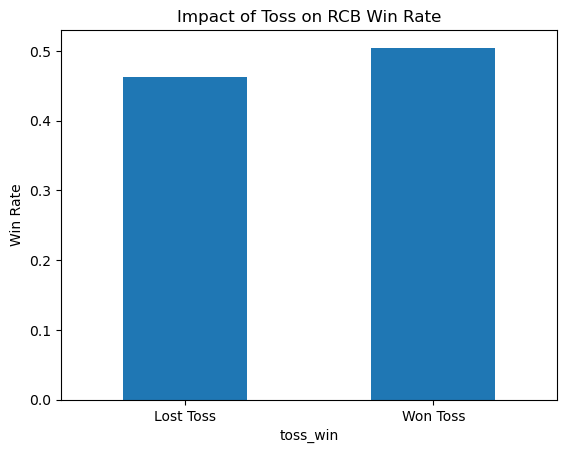

In [37]:
# Toss impact visualization
toss_data = rcb.groupby('toss_win')['rcb_win'].mean()

toss_data.plot(kind='bar')
plt.title("Impact of Toss on RCB Win Rate")
plt.ylabel("Win Rate")
plt.xticks([0,1], ['Lost Toss','Won Toss'], rotation=0)
plt.show()

### Insight:
Winning the toss provides only a **marginal advantage**, with win percentage increasing from **46.28% to 50.47%**.  
This indicates that toss decisions are not a major determinant of match outcomes for RCB.

## Batting First vs Chasing

In [21]:
def batting_first(row):
    if row['Team1'] == 'Royal Challengers Bangalore' and row['TossDecision'] == 'bat':
        return 1
    else:
        return 0

rcb['batting_first'] = rcb.apply(batting_first, axis=1)

rcb.groupby('batting_first')['rcb_win'].mean()

/var/folders/fx/f2krdn_50bggsht6f17h9r6w0000gn/T/ipykernel_1521/2494928445.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rcb['batting_first'] = rcb.apply(batting_first, axis=1)


batting_first
0    0.468750
1    0.558824
Name: rcb_win, dtype: float64

### Insight:
RCB performs significantly better when **batting first (55.88%)** compared to chasing (46.87%).  
This suggests that the team is more effective at **defending totals** rather than chasing targets, highlighting a potential weakness in pressure situations.

## Opponent-wise Performance

In [22]:
def get_opponent(row):
    if row['Team1'] == 'Royal Challengers Bangalore':
        return row['Team2']
    else:
        return row['Team1']

rcb['opponent'] = rcb.apply(get_opponent, axis=1)

opponent_stats = rcb.groupby('opponent')['rcb_win'].mean().sort_values()
opponent_stats

/var/folders/fx/f2krdn_50bggsht6f17h9r6w0000gn/T/ipykernel_1521/1342491939.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rcb['opponent'] = rcb.apply(get_opponent, axis=1)


opponent
Rising Pune Supergiant     0.000000
Punjab Kings               0.250000
Chennai Super Kings        0.344828
Sunrisers Hyderabad        0.428571
Delhi Capitals             0.428571
Mumbai Indians             0.433333
Deccan Chargers            0.454545
Kings XI Punjab            0.461538
Kolkata Knight Riders      0.466667
Rajasthan Royals           0.481481
Gujarat Titans             0.500000
Gujarat Lions              0.600000
Delhi Daredevils           0.666667
Kochi Tuskers Kerala       1.000000
Rising Pune Supergiants    1.000000
Lucknow Super Giants       1.000000
Pune Warriors              1.000000
Name: rcb_win, dtype: float64

In [42]:
# Create opponent column
rcb['opponent'] = rcb.apply(get_opponent, axis=1)

# Count number of matches vs each opponent
matches_count = rcb['opponent'].value_counts()

# Keep only teams with more than 5 matches
valid_teams = matches_count[matches_count > 5].index

# Filter dataset
filtered = rcb[rcb['opponent'].isin(valid_teams)]

# Calculate win rate
opponent_stats = filtered.groupby('opponent')['rcb_win'].mean().sort_values()

opponent_stats

/var/folders/fx/f2krdn_50bggsht6f17h9r6w0000gn/T/ipykernel_1521/3704752438.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rcb['opponent'] = rcb.apply(get_opponent, axis=1)


opponent
Chennai Super Kings      0.344828
Delhi Capitals           0.428571
Sunrisers Hyderabad      0.428571
Mumbai Indians           0.433333
Deccan Chargers          0.454545
Kings XI Punjab          0.461538
Kolkata Knight Riders    0.466667
Rajasthan Royals         0.481481
Delhi Daredevils         0.666667
Name: rcb_win, dtype: float64

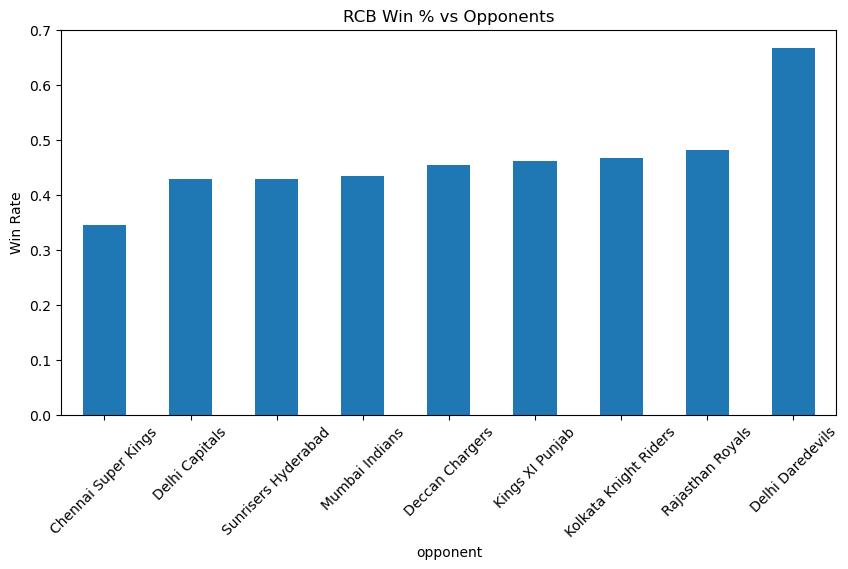

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
opponent_stats.plot(kind='bar')
plt.title("RCB Win % vs Opponents")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.show()

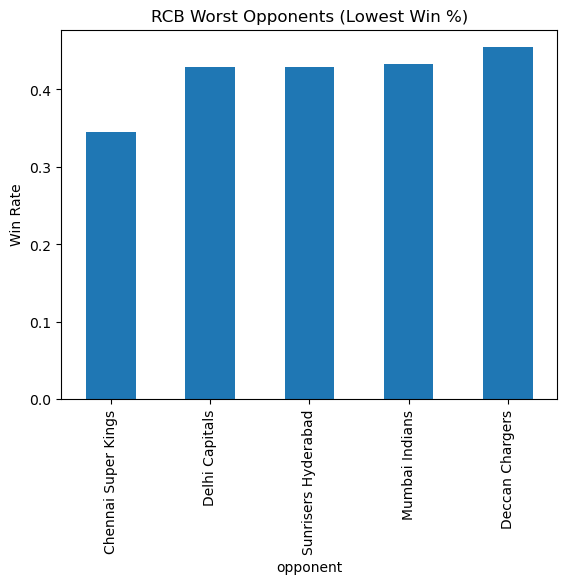

In [44]:
worst = opponent_stats.head(5)

worst.plot(kind='bar')
plt.title("RCB Worst Opponents (Lowest Win %)")
plt.ylabel("Win Rate")
plt.show()

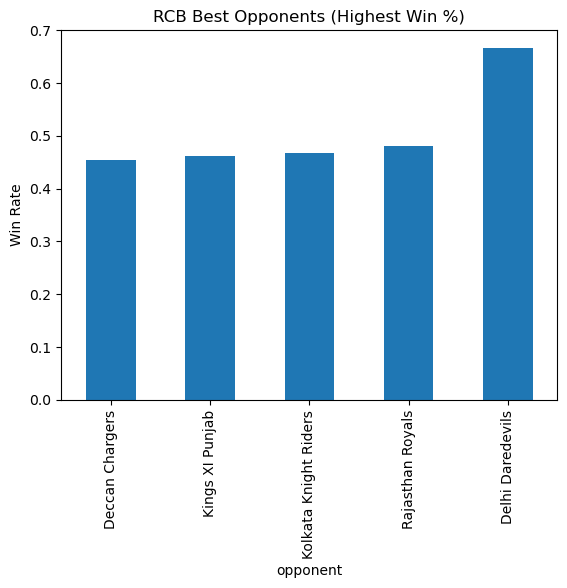

In [45]:
best = opponent_stats.tail(5)

best.plot(kind='bar')
plt.title("RCB Best Opponents (Highest Win %)")
plt.ylabel("Win Rate")
plt.show()

In [41]:
matches_count = rcb['opponent'].value_counts()

valid_teams = matches_count[matches_count > 5].index

filtered = rcb[rcb['opponent'].isin(valid_teams)]

opponent_stats = filtered.groupby('opponent')['rcb_win'].mean().sort_values()

### Insight:
To ensure reliable analysis, teams with fewer than 5 matches were excluded.  
This avoids misleading results from small sample sizes and provides a more accurate comparison of RCB’s performance across opponents.

## Virat Kohli Performance Impact

In [29]:
# Merge datasets using ID
merged = pd.merge(deliveries, matches, on='ID')

# Filter Virat Kohli data
kohli = merged[merged['batter'] == 'V Kohli']

# Runs scored per match
kohli_runs = kohli.groupby('ID')['batsman_run'].sum().reset_index()

# Add match result
kohli_runs = pd.merge(kohli_runs, matches[['ID','WinningTeam']], on='ID')

# Create win column
kohli_runs['rcb_win'] = kohli_runs['WinningTeam'].apply(
    lambda x: 1 if x == 'Royal Challengers Bangalore' else 0
)

# Compare performance
high = kohli_runs[kohli_runs['batsman_run'] >= 50]['rcb_win'].mean()
low = kohli_runs[kohli_runs['batsman_run'] < 50]['rcb_win'].mean()

print("Win % when Kohli scores 50+:", high)
print("Win % when Kohli scores <50:", low)

Win % when Kohli scores 50+: 0.52
Win % when Kohli scores <50: 0.46060606060606063


In [30]:
kohli_runs.head()

,ID,batsman_run,WinningTeam,rcb_win
0,335982,1,Kolkata Knight Riders,0
1,335985,23,Royal Challengers Bangalore,1
2,335992,13,Rajasthan Royals,0
3,335996,12,Chennai Super Kings,0
4,335998,1,Delhi Daredevils,0


### Insight:
RCB’s win rate increases from **46.06% to 52%** when Virat Kohli scores 50 or more runs.  

This indicates a **moderate dependency on top-order performance**, where strong contributions from key players improve match outcomes but are not solely decisive.

In [31]:
print("----- KEY INSIGHTS: RCB PERFORMANCE ANALYSIS -----\n")

# 1. Overall Win %
win_rate = rcb['rcb_win'].mean() * 100
print(f"Overall Win Percentage: {win_rate:.2f}%\n")

# 2. Toss Impact
toss_win_rate = rcb[rcb['toss_win'] == 1]['rcb_win'].mean() * 100
toss_loss_rate = rcb[rcb['toss_win'] == 0]['rcb_win'].mean() * 100

print("Toss Impact:")
print(f"- Win % after winning toss: {toss_win_rate:.2f}%")
print(f"- Win % after losing toss: {toss_loss_rate:.2f}%\n")

# 3. Batting Strategy
bat_first = rcb[rcb['batting_first'] == 1]['rcb_win'].mean() * 100
chasing = rcb[rcb['batting_first'] == 0]['rcb_win'].mean() * 100

print("Batting Strategy:")
print(f"- Win % batting first: {bat_first:.2f}%")
print(f"- Win % while chasing: {chasing:.2f}%\n")

# 4. Worst Opponents (bottom 3)
worst = opponent_stats.head(3)

print("Challenging Opponents:")
for team, value in worst.items():
    print(f"- {team}: {value*100:.2f}% win rate")

print()

# 5. Kohli Impact
print("Virat Kohli Impact:")
print(f"- Win % when Kohli scores 50+: {high*100:.2f}%")
print(f"- Win % when Kohli scores <50: {low*100:.2f}%")

----- KEY INSIGHTS: RCB PERFORMANCE ANALYSIS -----

Overall Win Percentage: 48.23%

Toss Impact:
- Win % after winning toss: 50.48%
- Win % after losing toss: 46.28%

Batting Strategy:
- Win % batting first: 55.88%
- Win % while chasing: 46.88%

Challenging Opponents:
- Rising Pune Supergiant: 0.00% win rate
- Punjab Kings: 25.00% win rate
- Chennai Super Kings: 34.48% win rate

Virat Kohli Impact:
- Win % when Kohli scores 50+: 52.00%
- Win % when Kohli scores <50: 46.06%


## Final Conclusion

This analysis highlights that Royal Challengers Bangalore is an inconsistent team with a win rate below 50%.

The team performs significantly better when batting first, suggesting stronger defensive capabilities rather than chasing ability.

Performance against stronger teams such as CSK and MI remains a key weakness.

Additionally, while Virat Kohli’s performance positively impacts match outcomes, the dependency is moderate rather than absolute.

Overall, strategic improvements in chasing and consistency against top-tier teams could enhance performance.